First 5 rows:
   Index  Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0   1001   58138        0         0       58       635         88   
1   1002   46344        1         1       38        11          1   
2   1003   71613        0         0       26       426         49   
3   1004   26646        1         0       26        11          4   
4   1005   58293        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  MntSweetProducts  ...  AcceptedCmp2  \
0              546              172                88  ...             0   
1                6                2                 1  ...             0   
2              127              111                21  ...             0   
3               20               10                 3  ...             0   
4              118               46                27  ...             0   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  AcceptedCmpOverall  Complain  \
0             0             0        

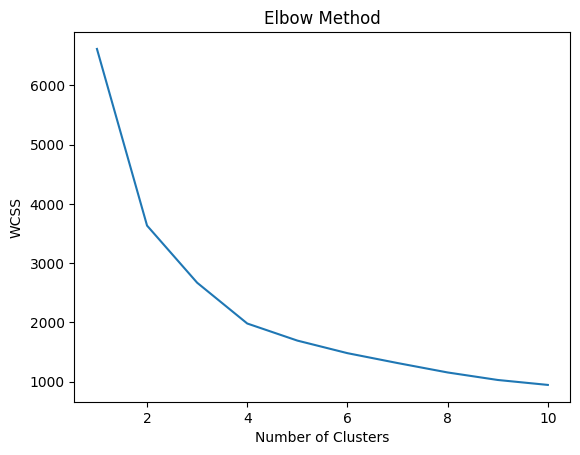

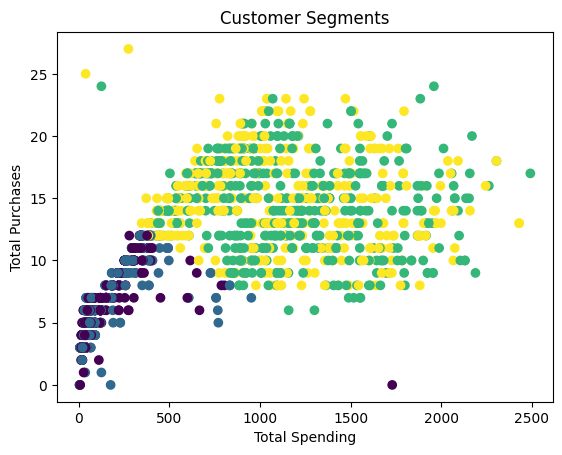

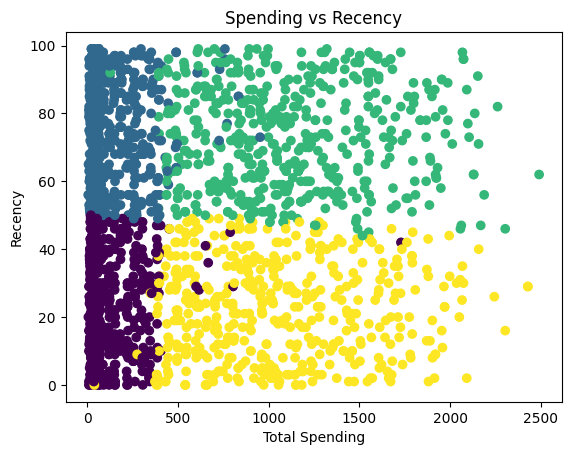


Cluster-wise Analysis:
         Total_Spending  Total_Purchases    Recency
Cluster                                            
0            115.103161         5.861897  24.735441
1            136.048576         6.204355  74.619765
2           1118.940270        14.323699  72.581888
3           1044.606557        14.799180  22.502049

Segmented data saved as 'segmented_customers.csv'


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
df = pd.read_excel('/content/iFood.xlsx')

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
df.fillna(df.mean(numeric_only=True), inplace=True)
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts']].sum(axis=1)
df['Total_Purchases'] = df[['NumWebPurchases', 'NumStorePurchases']].sum(axis=1)
features = df[['Total_Spending', 'Total_Purchases', 'Recency']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)
plt.figure()
plt.scatter(df['Total_Spending'], df['Total_Purchases'], c=df['Cluster'])
plt.xlabel('Total Spending')
plt.ylabel('Total Purchases')
plt.title('Customer Segments')
plt.show()
plt.figure()
plt.scatter(df['Total_Spending'], df['Recency'], c=df['Cluster'])
plt.xlabel('Total Spending')
plt.ylabel('Recency')
plt.title('Spending vs Recency')
plt.show()
print("\nCluster-wise Analysis:")
cluster_analysis = df.groupby('Cluster')[['Total_Spending', 'Total_Purchases', 'Recency']].mean()
print(cluster_analysis)
df.to_csv('segmented_customers.csv', index=False)
print("\nSegmented data saved as 'segmented_customers.csv'")